In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/gurgaon_properties_cleaned_v2.csv')

In [3]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,indiabulls centrum park,sector 103,1.34,7882.0,1700.08,Super Built up area 1725(160.26 sq.m.)Carpet a...,3,3,3+,...,1725.00,NaN,1700.0,1,1,1,1,0,1,38
1,flat,mapsko royale ville,sector 82,1.15,6424.0,1790.16,Super Built up area 1790(166.3 sq.m.),3,4,2,...,1790.00,NaN,NaN,0,1,0,1,0,1,104
2,flat,ss the leaf,sector 85,2.15,10924.0,1968.14,Super Built up area 2812(261.24 sq.m.)Carpet a...,4,5,3+,...,2812.00,NaN,1968.0,0,1,0,0,0,0,156
3,flat,vatika the seven lamps,sector 82,0.89,8850.0,1005.65,Super Built up area 1428.08(132.67 sq.m.)Carpe...,2,2,2,...,1428.08,NaN,1000.0,1,0,0,0,0,1,129
4,flat,ats triumph,sector 104,1.75,7641.0,2290.28,Super Built up area 2290(212.75 sq.m.)Carpet a...,3,4,3+,...,2290.00,NaN,1800.0,1,1,0,1,1,1,21


In [4]:
df.shape

(3803, 23)

In [5]:
df.duplicated().sum()

np.int64(126)

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.shape

(3677, 23)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3677 entries, 0 to 3802
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3677 non-null   object 
 1   society              3676 non-null   object 
 2   sector               3677 non-null   object 
 3   price                3660 non-null   float64
 4   price_per_sqft       3660 non-null   float64
 5   area                 3660 non-null   float64
 6   areaWithType         3677 non-null   object 
 7   bedRoom              3677 non-null   int64  
 8   bathroom             3677 non-null   int64  
 9   balcony              3677 non-null   object 
 10  floorNum             3658 non-null   float64
 11  facing               2633 non-null   object 
 12  agePossession        3677 non-null   object 
 13  super_built_up_area  1872 non-null   float64
 14  built_up_area        1691 non-null   float64
 15  carpet_area          1877 non-null   float6

# property_type

<Axes: xlabel='property_type'>

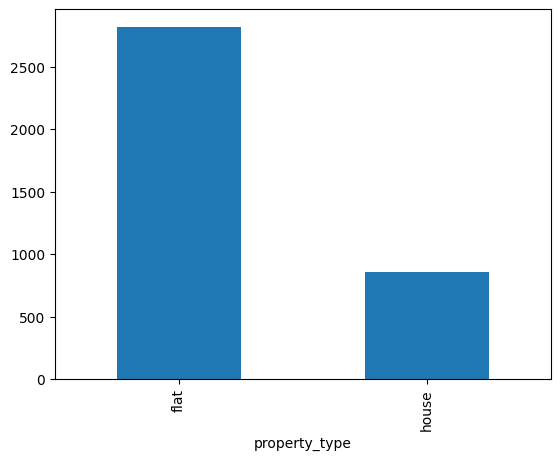

In [9]:
df['property_type'].value_counts().plot(kind='bar')

## Observations

*   Flats are in majority(75 percent) and there are less number of houses
(~25 percent)
*   No missing values


# society

In [10]:
df['society'].isnull().sum()

np.int64(1)

In [11]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2874,flat,NaN,sector 78,0.6,3692.0,1625.14,Built Up area: 1625 (150.97 sq.m.),2,2,0,...,NaN,1625.0,NaN,0,0,0,0,0,0,0


In [12]:
df['society'].value_counts().shape

(676,)

In [13]:
df['society'].value_counts()

,count
society,
independent,485
tulip violet,75
ss the leaf,73
dlf new town heights,42
shapoorji pallonji joyville gurugram,42
...,...
the laburnum,1
eros wembley estate,1
whiteland the aspen,1


In [14]:
df[df['society']!='independent']['society'].count()

np.int64(3191)

In [15]:
df[df['society']!='independent']['society'].value_counts(normalize = True).cumsum().head(75)

,proportion
society,
tulip violet,0.023504
ss the leaf,0.046380
shapoorji pallonji joyville gurugram,0.059542
dlf new town heights,0.072704
signature global park,0.083673
...,...
umang winter hills,0.489815
puri emerald bay,0.493889
dlf the primus,0.497963


In [16]:
society_counts = df['society'].value_counts()

# Frequency distribution for societies
frequency_bins = {
    "Very High (>100)" : int((society_counts > 100).sum()),
    "High (50-100)" : int(((100>=society_counts)&(society_counts>=50)).sum()),
    "Average (10-49)" : int(((49>=society_counts)&(society_counts>=10)).sum()),
    "Low (2-9)" : int(((9>=society_counts)&(society_counts>=2)).sum()),
    "Very Low (1)" : int((society_counts==1).sum())
}
frequency_bins

{'Very High (>100)': 1,
 'High (50-100)': 2,
 'Average (10-49)': 92,
 'Low (2-9)': 274,
 'Very Low (1)': 307}

<Axes: xlabel='society'>

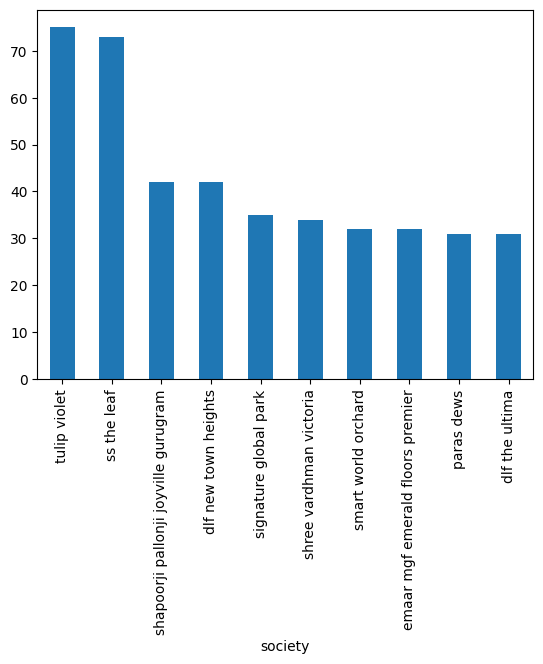

In [17]:
#top 10 societies
df[df['society'] != 'independent']['society'].value_counts().head(10).plot(kind='bar')

# Observations




*   Around 13% properties comes under independent tag.
*   There are 675 societies.
*   1 missing value
*   The top 75 societies have 50 percent of the preperties and the
rest 50 percent of the properties come under the remaining 600 societies


  1.   Very High (>100): Only 1 society has more than 100 listings.
  2.   High (50-100): 2 societies have between 50 to 100 listings.
  3.   Average (10-49): 92 societies fall in this range with 10 to 49 listings each.
  4.   Low (2-9): 274 societies have between 2 to 9 listings.
  5.   Very Low (1): A significant number, 307 societies, have only 1 listing.

















# Sector

In [18]:
#unique sectors
df['sector'].value_counts().shape

(153,)

<Axes: xlabel='sector'>

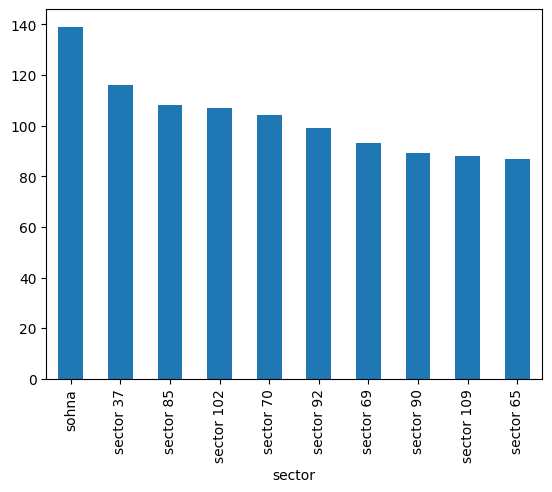

In [19]:
#top 10 sectors
df['sector'].value_counts().head(10).plot(kind='bar')

In [20]:
# Frequency distribution for sectors
sector_counts = df['sector'].value_counts()

sector_frequency_bins = {
    "Very High (>100)": (sector_counts > 100).sum(),
    "High (50-100)": ((sector_counts >= 50) & (sector_counts <= 100)).sum(),
    "Average (10-49)": ((sector_counts >= 10) & (sector_counts < 50)).sum(),
    "Low (2-9)": ((sector_counts > 1) & (sector_counts < 10)).sum(),
    "Very Low (1)": (sector_counts == 1).sum()
}

sector_frequency_bins

{'Very High (>100)': np.int64(5),
 'High (50-100)': np.int64(18),
 'Average (10-49)': np.int64(63),
 'Low (2-9)': np.int64(67),
 'Very Low (1)': np.int64(0)}

# Observations

* There are a total of 153 unique sectors in the dataset.
* Frequency distribution of sectors:
1. Very High (>100): 5 sectors have more than 100 listings.
2. High (50-100): 18 sectors have between 50 to 100 listings.
3. Average (10-49): A majority, 63 sectors, fall in this range with 10 to 49 listings each.
4. Low (2-9): 67 sectors have between 2 to 9 listings.
5. Very Low (1): Interestingly, there are no sectors with only 1 listing.

# Price

In [21]:
df['price'].isnull().sum()

np.int64(17)

In [22]:
df['price'].describe()

,price
count,3660.000000
mean,2.533238
std,2.977140
min,0.070000
25%,0.950000
50%,1.520000
75%,2.750000
max,31.500000


<Axes: xlabel='price', ylabel='Count'>

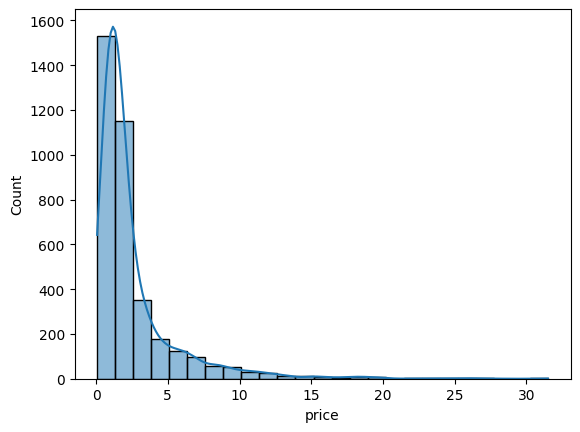

In [23]:
sns.histplot(df['price'], kde=True, bins=25)

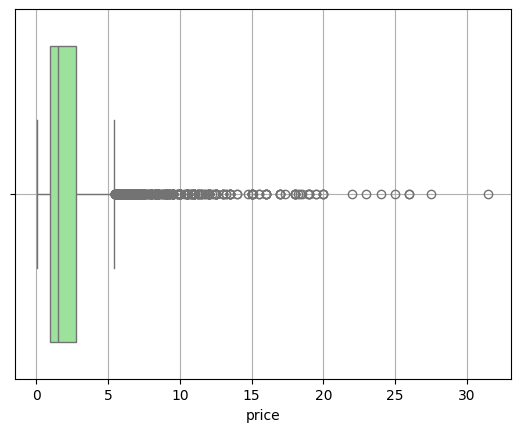

In [24]:
sns.boxplot( x=df['price'], color = 'lightgreen')
plt.grid()

# Descriptive Statistics:

    * Count: There are 3,660 non-missing price entries.
    * Mean Price: The average price is approximately 2.53 crores.
    * Median Price: The median (or 50th percentile) price is 1.52 crores.
    * Standard Deviation: The prices have a standard deviation of 2.98, indicating variability in the prices.
    * Range: Prices range from a minimum of 0.07 crores to a maximum of 31.5 crores.
    * IQR: The interquartile range (difference between 75th and 25th percentile) is from 0.95 crores to 2.75 crores.
# Visualizations:

    * Distribution: The histogram indicates that most properties are priced in the lower range (below 5 crores), with a few properties going beyond 10 crores.

    * Box Plot: The box plot showcases the spread of the data and potential outliers. Properties priced above approximately 10 crores might be considered outliers as they lie beyond the upper whisker of the box plot.

### Missing Values: There are 17 missing values in the price column.

In [25]:
# Skewness and Kurtosis
skewness = df['price'].skew()
kurtosis = df['price'].kurtosis()

In [26]:
print('skewness : ', skewness)
print('kurtosis : ', kurtosis)

skewness :  3.279383355811449
kurtosis :  14.96882140110269


# Skewness:
The price distribution has a skewness of approximately 3.28, indicating a positive skew. This means that the distribution tail is skewed to the right, which aligns with our observation from the histogram where most properties have prices on the lower end with a few high-priced properties.

# Kurtosis:
The kurtosis value is approximately 14.93. A kurtosis value greater than 3 indicates a distribution with heavier tails and more outliers compared to a normal distribution.

In [27]:
# Quantile Analysis

quantiles = df['price'].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
quantiles

,price
0.01,0.250
0.05,0.370
0.25,0.950
0.50,1.520
0.75,2.750
0.95,8.500
0.99,15.264


# Quantile Analysis:

* 1% Quantile: Only 1% of properties are priced below 0.25 crores.
* 5% Quantile: 5% of properties are priced below 0.37 crores.
* 25% Quantile: 25% of properties are priced below 0.95 crores.
* 50% Quantile: 50% of properties are priced below 1.52 crores.
* 75% Quantile: 75% of properties are priced below 2.75 crores.
* 95% Quantile: 95% of properties are priced below 8.5 crores.
* 99% Quantile: 99% of properties are priced below 15.26 crores, indicating that very few properties are priced above this value.

In [28]:
# Identify potential outliers using IQR method

Q1 = df['price'].describe()['25%']
Q3 = df['price'].describe()['75%']
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [29]:
print('Lower Bound : ',lower_bound)
print('Upper Bound : ',upper_bound)

Lower Bound :  -1.7500000000000002
Upper Bound :  5.45


In [30]:
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

In [31]:
outliers['price'].describe()

,price
count,426.000000
mean,9.216056
std,4.058398
min,5.460000
25%,6.445000
50%,8.000000
75%,10.557500
max,31.500000


# Outliers Analysis (using IQR method):

* Based on the IQR method, there are 426 properties considered as outliers.
* These outliers have an average price of approximately 9.21 crores.
* The range for these outliers is from 5.46 crores to 31.5 crores.

<Axes: xlabel='price'>

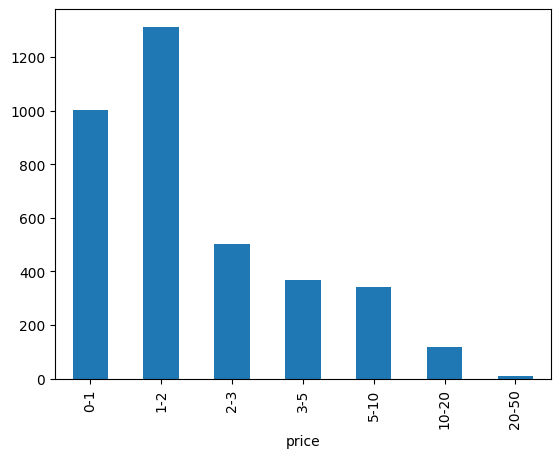

In [32]:
# Price Binning

bins = [0,1,2,3,5,10,20,50]
bins_labels = ['0-1', '1-2', '2-3', '3-5', '5-10', '10-20', '20-50']
pd.cut(df['price'], bins=bins, labels=bins_labels, right = False).value_counts().sort_index().plot(kind='bar')

* The majority of properties are priced in the "0-1 crores" and "1-2  crores" ranges.
* There's a significant drop in the number of properties priced above "5 crores."

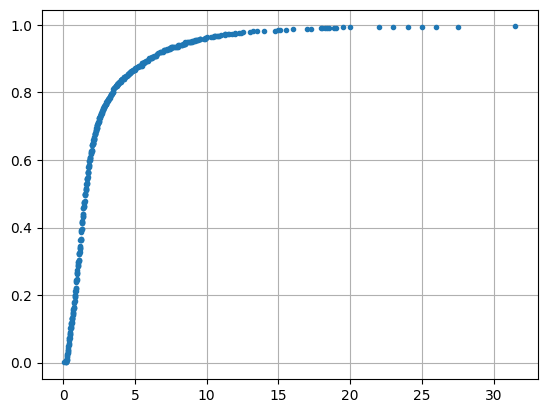

In [33]:
#ecdf plot

ecdf = df['price'].value_counts().sort_index().cumsum()/len(df['price'])
plt.plot(ecdf.index, ecdf, marker = '.', linestyle = 'none')
plt.grid()

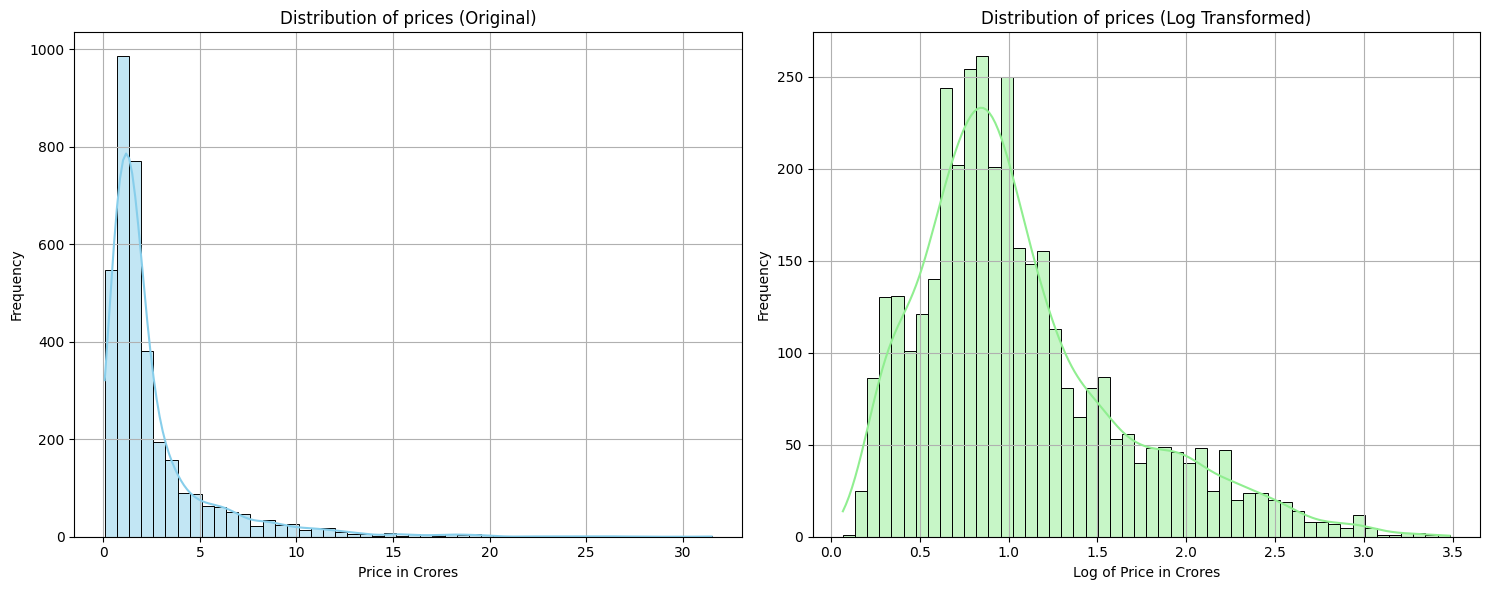

In [34]:
plt.figure(figsize=(15,6))

# Distribution plot without log transformation

plt.subplot(1,2,1)
sns.histplot( x=df['price'], kde = True, bins = 50, color = 'skyblue')
plt.grid()
plt.title('Distribution of prices (Original)')
plt.xlabel('Price in Crores')
plt.ylabel('Frequency')

# Distribution plot with log transformation

plt.subplot(1,2,2)
sns.histplot( x = np.log1p(df['price']), kde = True, bins = 50, color = 'lightgreen')
plt.grid()
plt.title('Distribution of prices (Log Transformed)')
plt.xlabel('Log of Price in Crores')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

np.log1p(x): This function computes the natural logarithm of 1+x. It's designed to provide more accurate results for values of x that are very close to zero.

Using np.log1p helps in transforming the price column while ensuring that any value (including zero, if present) is handled appropriately. When we need to reverse the transformation, we can use np.expm1 which computes e^x-1

In [35]:
skewness = np.log1p(df['price']).skew()
kurtosis = np.log1p(df['price']).kurtosis()

In [36]:
print('skewness : ', skewness)
print('kurtosis : ', kurtosis)

skewness :  1.0710014207243097
kurtosis :  0.9557460725573184


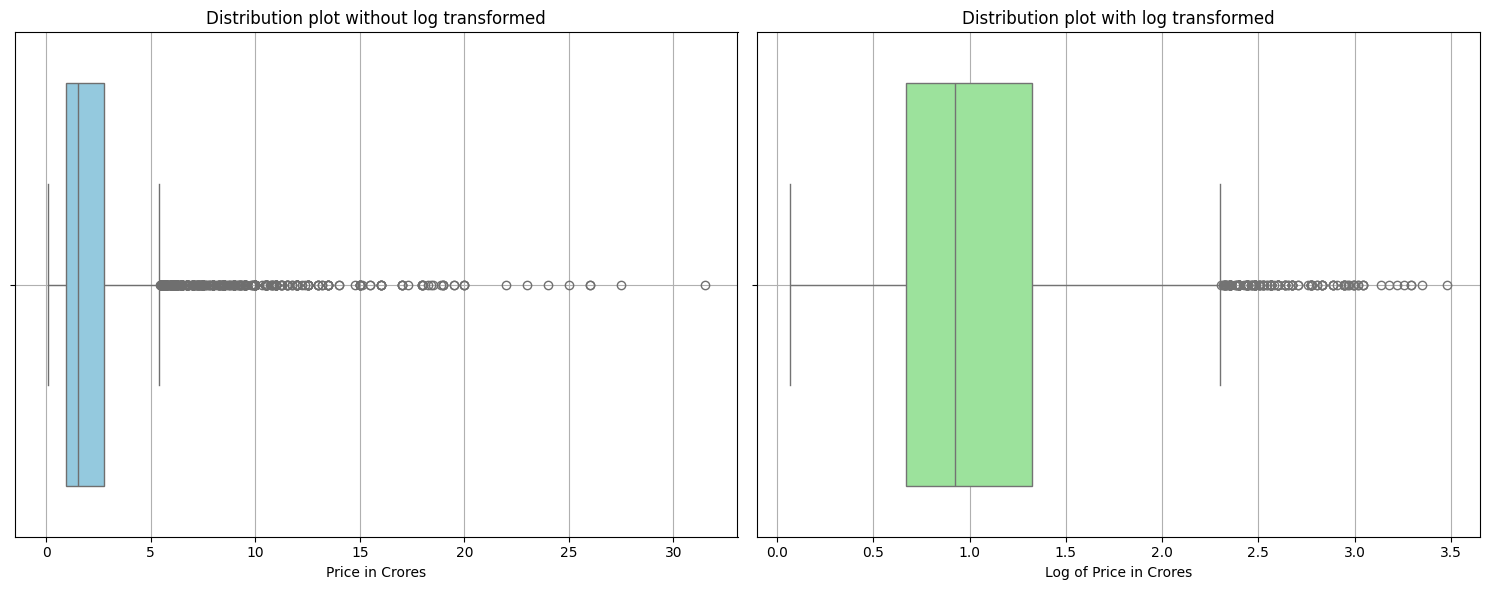

In [37]:
plt.figure(figsize=(15,6))


# Distribution plot without log transformed

plt.subplot(1,2,1)
sns.boxplot(x = df['price'], color='skyblue')
plt.grid()
plt.title('Distribution plot without log transformed')
plt.xlabel('Price in Crores')

#Distribution plot with log transformed

plt.subplot(1,2,2)
sns.boxplot(x = np.log1p(df['price']), color='lightgreen')
plt.grid()
plt.title('Distribution plot with log transformed')
plt.xlabel('Log of Price in Crores')

plt.tight_layout()
plt.show()

# price_per_sqft

In [38]:
df['price_per_sqft'].isnull().sum()

np.int64(17)

In [39]:
df['price_per_sqft'].describe()

,price_per_sqft
count,3660.000000
mean,13895.265847
std,23121.356568
min,4.000000
25%,6817.250000
50%,9020.000000
75%,13888.250000
max,600000.000000


<Axes: xlabel='price_per_sqft', ylabel='Count'>

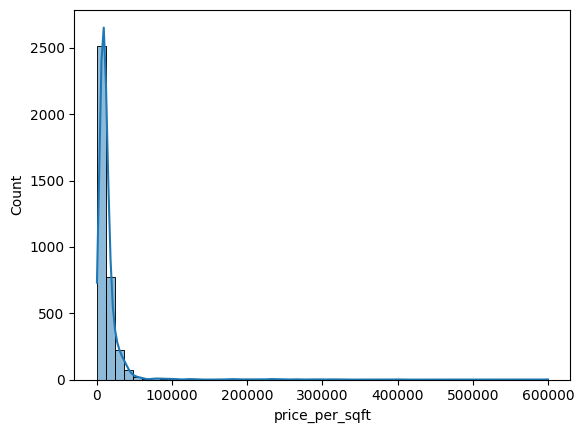

In [40]:
sns.histplot(x=df['price_per_sqft'], kde=True, bins=50)


Most properties have a price_per_sqft ranging between approximately ₹0 and ₹40,000. There is a significant concentration in the lower range, with a few properties having exceptionally high price_per_sqft.

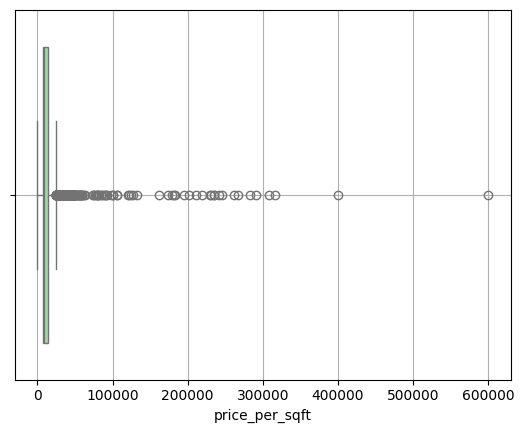

In [41]:
sns.boxplot(x=df['price_per_sqft'], color='lightgreen')
plt.grid()

The box plot clearly shows several outliers, especially on the higher side. The interquartile range (IQR) is relatively compact, but there are many data points beyond the "whiskers" of the box plot, indicating potential outliers

### Observations

* Potential Outliers
* Right Skewed
* 17 missing values

# bedRoom

In [42]:
df['bedRoom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bedRoom'>

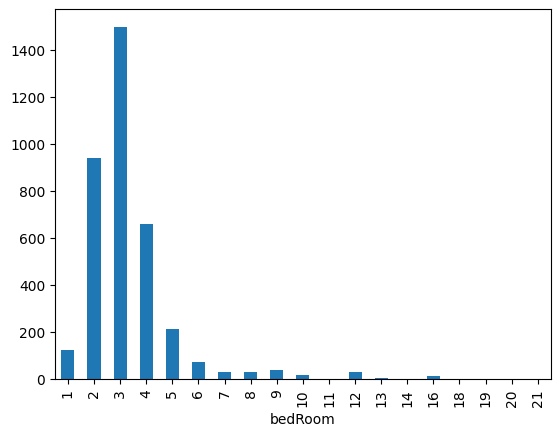

In [43]:
df['bedRoom'].value_counts().sort_index().plot(kind='bar')

Text(0.5, 1.0, 'Bedroom Distribution')

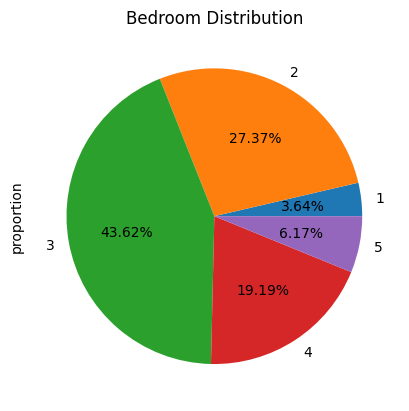

In [44]:
df['bedRoom'].value_counts(normalize = True).sort_index().head().plot(kind='pie', autopct = '%0.2f%%')
plt.title('Bedroom Distribution')

# bathroom

In [45]:
df['bathroom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bathroom'>

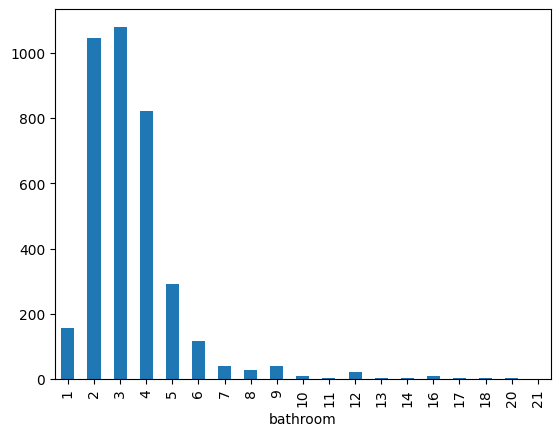

In [46]:
df['bathroom'].value_counts().sort_index().plot(kind='bar')

<Axes: title={'center': 'Bathroom distribution'}, ylabel='proportion'>

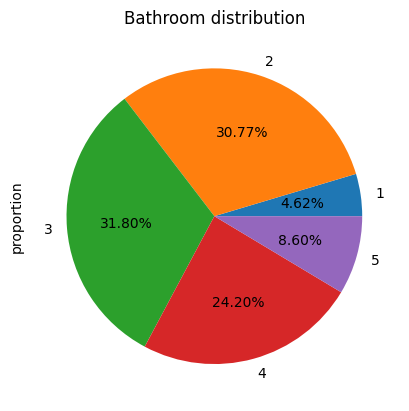

In [47]:
df['bathroom'].value_counts(normalize=True).sort_index().head().plot(kind='pie', autopct = '%0.2f%%', title = 'Bathroom distribution')

# balcony

In [48]:
df['balcony'].isnull().sum()

np.int64(0)

<Axes: xlabel='balcony'>

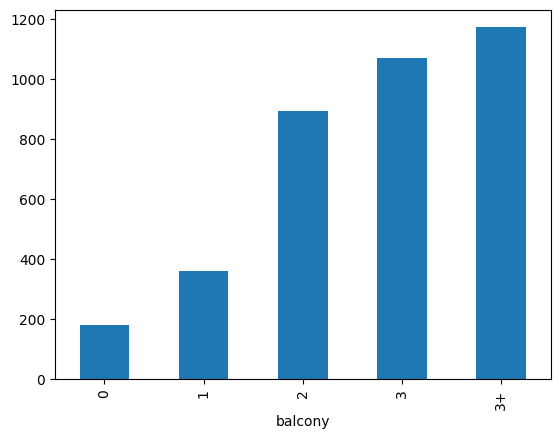

In [49]:
df['balcony'].value_counts().sort_index().plot(kind='bar')

<Axes: title={'center': 'Balcony distribution'}, ylabel='proportion'>

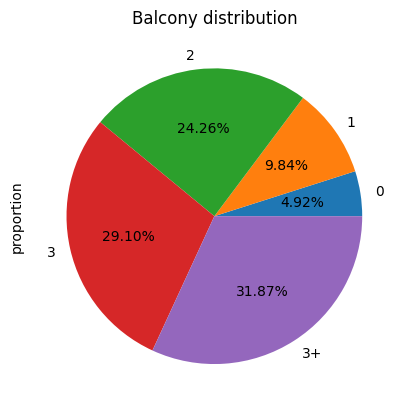

In [50]:
df['balcony'].value_counts(normalize=True).sort_index().plot(kind='pie', autopct = '%0.2f%%', title = 'Balcony distribution')

# floorNum

In [51]:
df.iloc[:,10:].head()

,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,12.0,East,relatively new,1725.00,NaN,1700.0,1,1,1,1,0,1,38
1,15.0,North-East,relatively new,1790.00,NaN,NaN,0,1,0,1,0,1,104
2,6.0,South,relatively new,2812.00,NaN,1968.0,0,1,0,0,0,0,156
3,14.0,East,relatively new,1428.08,NaN,1000.0,1,0,0,0,0,1,129
4,12.0,North-West,relatively new,2290.00,NaN,1800.0,1,1,0,1,1,1,21


In [52]:
df['floorNum'].isnull().sum()

np.int64(19)

In [53]:
df['floorNum'].describe()

,floorNum
count,3658.000000
mean,6.792510
std,6.008323
min,0.000000
25%,2.000000
50%,5.000000
75%,10.000000
max,51.000000


<Axes: xlabel='floorNum'>

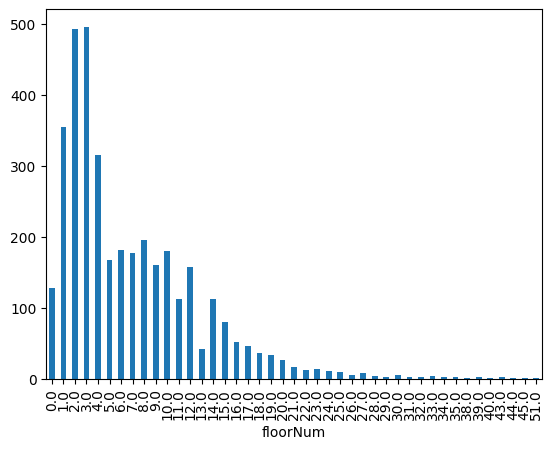

In [54]:
df['floorNum'].value_counts().sort_index().plot(kind='bar')

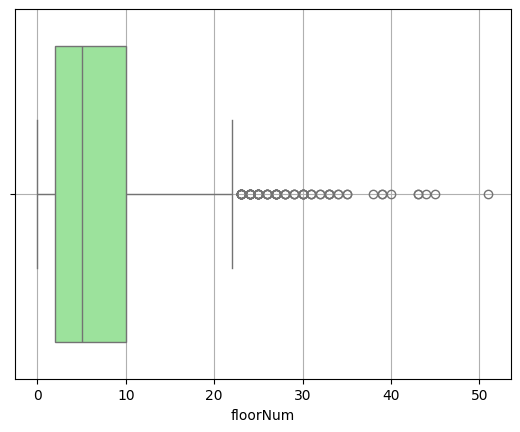

In [55]:
sns.boxplot(x=df['floorNum'], color='lightgreen')
plt.grid()

* The majority of the properties lie between the ground floor (0) and the 25th floor.
* Floors 1 to 4 are particularly common, with the 3rd floor being the most frequent.
* There are a few properties located at higher floors, but their frequency is much lower.
* The box plot reveals that the majority of the properties are concentrated around the lower floors. The interquartile range (IQR) lies between approximately the 2nd and 10th floors.
* Data points beyond the "whiskers" of the box plot, especially on the higher side, indicate potential outliers.

# facing

In [56]:
df['facing'].isnull().sum()

np.int64(1044)

In [57]:
df['facing'].fillna(value='NA', inplace = True)

/tmp/ipython-input-2510641887.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['facing'].fillna(value='NA', inplace = True)


In [58]:
df['facing'].value_counts()

,count
facing,
NA,1044
North-East,625
East,622
North,387
West,250
South,231
North-West,191
South-East,174
South-West,153


Will do multi-variate analysis on this feature with price feature

# agePossession

In [59]:
df['agePossession'].isnull().sum()

np.int64(0)

In [91]:
df['agePossession'].value_counts()

,count
agePossession,
relatively new,1642
New Property,595
moderately old,562
undefined,310
Old Property,304
Under Construction,264


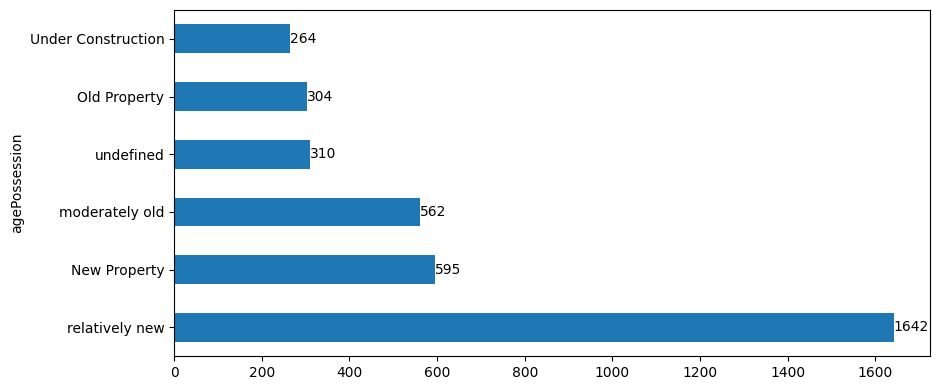

In [92]:
plt.figure(figsize=(9.5,4))
ax = df['agePossession'].value_counts().plot(kind='barh')
ax.bar_label(ax.containers[0], fmt='%d', label_type='edge')
plt.tight_layout()

# Area

## super_built_up_area

In [93]:
df['super_built_up_area'].isnull().sum()

np.int64(1805)

In [97]:
df['super_built_up_area'].describe()

,super_built_up_area
count,1872.000000
mean,1924.395059
std,764.926545
min,89.000000
25%,1478.000000
50%,1828.000000
75%,2215.000000
max,10000.000000


<Axes: xlabel='super_built_up_area', ylabel='Count'>

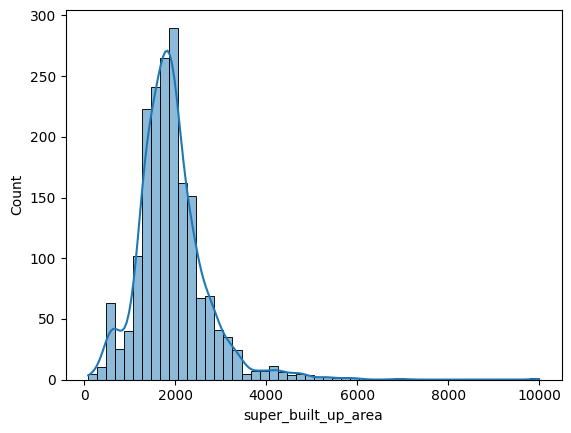

In [100]:
sns.histplot(x=df['super_built_up_area'].dropna(), kde=True, bins=50)

<Axes: xlabel='super_built_up_area'>

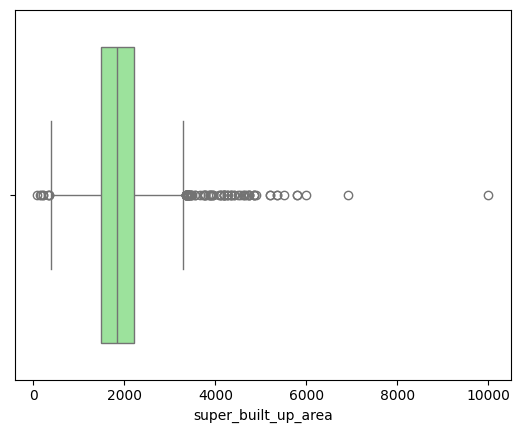

In [107]:
sns.boxplot(x=df['super_built_up_area'].dropna(), color='lightgreen')

* Most properties have a super built-up area ranging between approximately 1,000 sq.ft and 2,500 sq.ft.
* There are a few properties with a significantly larger area, leading to a right-skewed distribution.
* The interquartile range (IQR) lies between roughly 1,480 sq.ft and 2,215 sq.ft, indicating that the middle 50% of the properties fall within this range.
* There are several data points beyond the upper "whisker" of the box plot, indicating potential outliers. These are properties with an unusually large super built-up area.



## built_up_area

In [108]:
df['built_up_area'].isnull().sum()

np.int64(1986)

In [109]:
df['built_up_area'].describe()

,built_up_area
count,1691.000000
mean,2378.230626
std,17937.361114
min,2.000000
25%,1100.000000
50%,1650.000000
75%,2400.000000
max,737147.000000


<Axes: xlabel='built_up_area', ylabel='Count'>

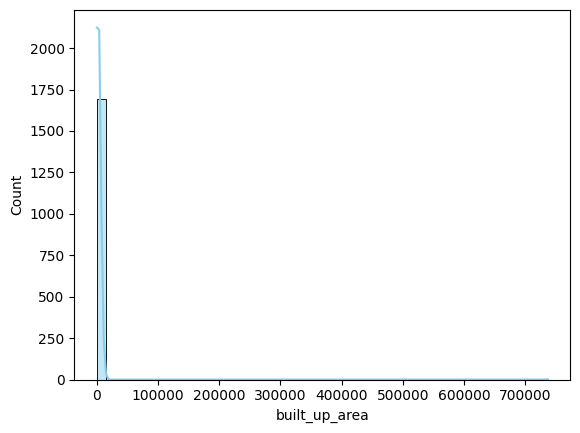

In [111]:
sns.histplot(x=df['built_up_area'].dropna(),kde=True, bins=50, color='skyblue')

<Axes: xlabel='built_up_area'>

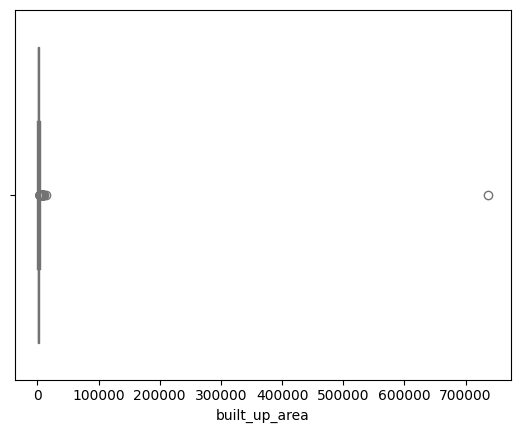

In [112]:
sns.boxplot(x=df['built_up_area'].dropna(), color='lightgreen')

* Most properties have a built-up area ranging roughly between 500 sq.ft and 3,500 sq.ft.
* There are very few properties with a much larger built-up area, leading to a highly right-skewed distribution.
* The box plot confirms the presence of significant outliers on the higher side. The data's interquartile range (IQR) is relatively compact, but the "whiskers" of the box plot are stretched due to the outliers.

The presence of extreme values, especially on the higher side, suggests that there may be outliers or data errors (Most Probably). This could also be due to some properties being exceptionally large, like a commercial complex or an entire building being listed

## Carpet area

In [113]:
df['carpet_area'].isnull().sum()

np.int64(1800)

In [114]:
df['carpet_area'].describe()

,carpet_area
count,1877.000000
mean,2524.478162
std,22769.613688
min,15.000000
25%,834.960000
50%,1300.000000
75%,1785.000000
max,607936.000000


<Axes: xlabel='carpet_area', ylabel='Count'>

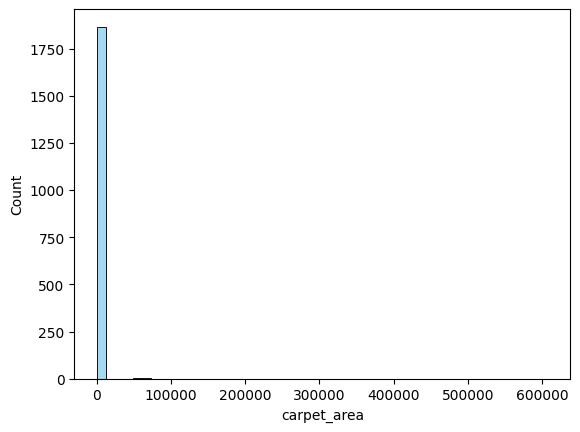

In [119]:
sns.histplot(x=df['carpet_area'].dropna(), kde = False, bins=50, color = 'skyblue')

<Axes: xlabel='carpet_area'>

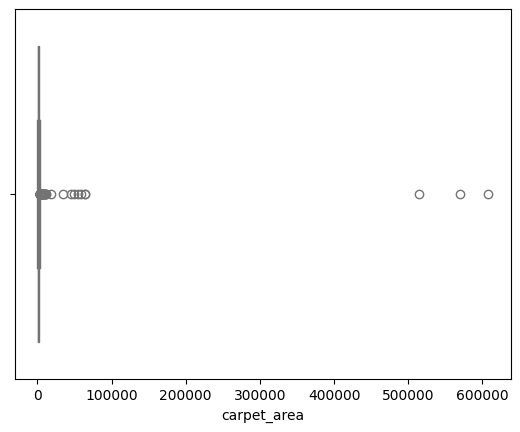

In [118]:
sns.boxplot(x=df['carpet_area'].dropna(), color='lightgreen')

In [120]:
df.iloc[:,16:]

,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,1,1,1,1,0,1,38
1,0,1,0,1,0,1,104
2,0,1,0,0,0,0,156
3,1,0,0,0,0,1,129
4,1,1,0,1,1,1,21
...,...,...,...,...,...,...,...
3798,0,1,0,0,0,0,108
3799,1,0,0,0,0,1,117
3800,0,0,0,0,0,1,0
3801,0,0,0,0,1,0,95


# Additional Rooms

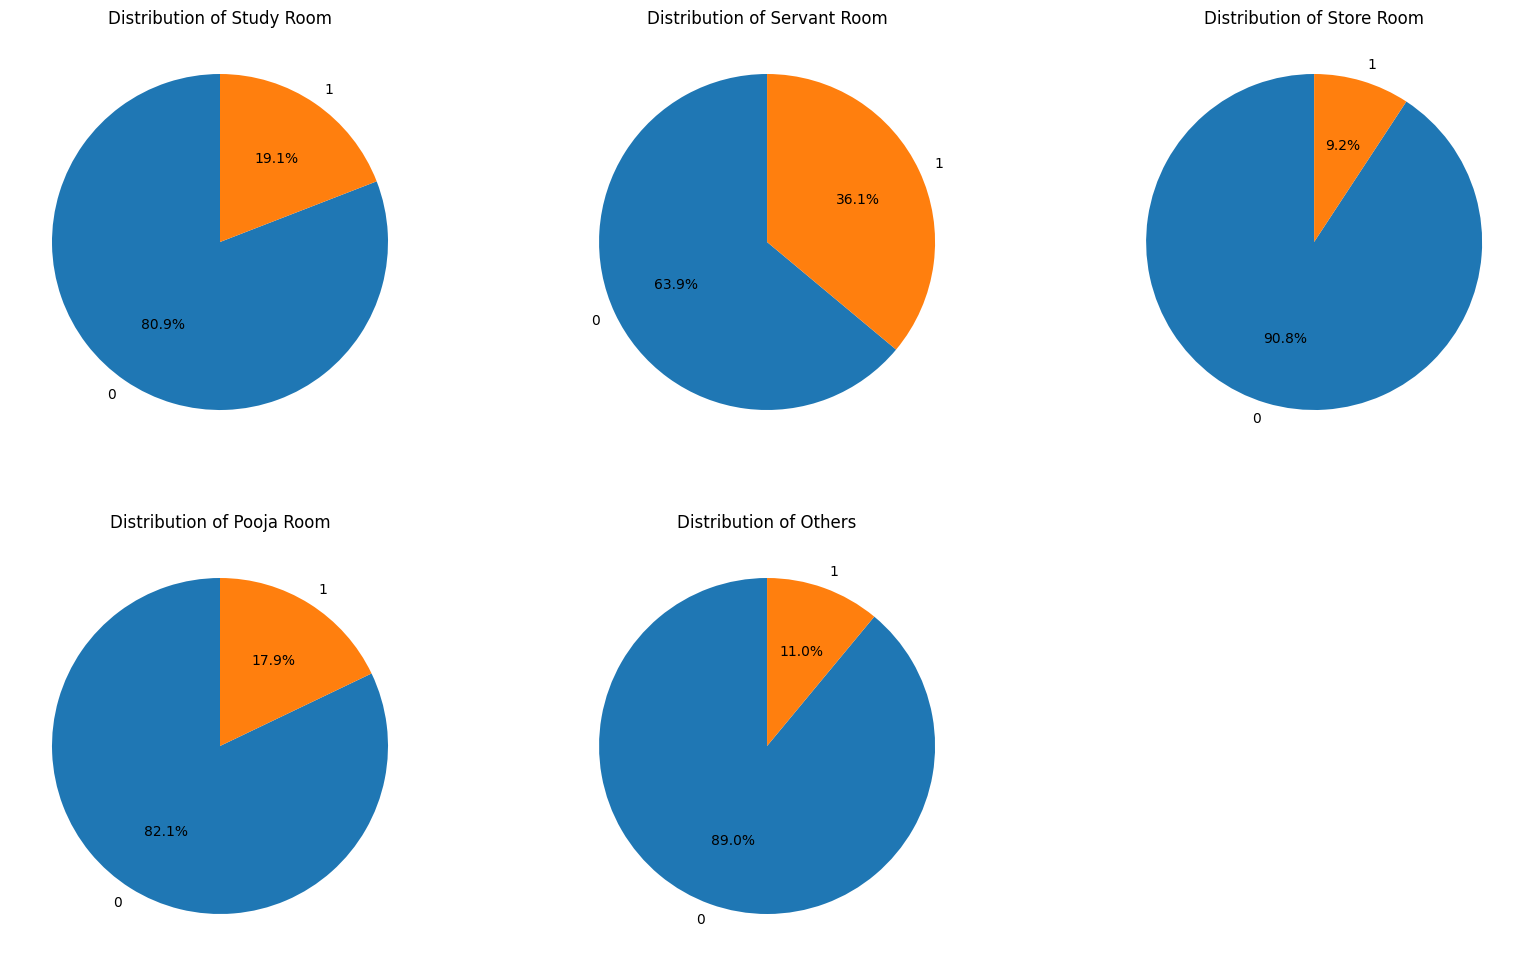

In [138]:
plt.figure(figsize=(20,12))

# Create a subplot of pie charts for each room type

for idx, room_type in enumerate(['study room', 'servant room',	'store room', 'pooja room',	'others'], start=1):

  ax = plt.subplot(2,3, idx)
  df[room_type].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle = 90, ax = ax )
  plt.title(f'Distribution of {room_type.title()}')
  ax.set_ylabel("")

# Furnishing Type

In [140]:
df["furnishing_type"].isnull().sum()

np.int64(0)

In [152]:
df['furnishing_type'].value_counts()

,count
furnishing_type,
0,2434
1,1042
2,201


<Axes: title={'center': 'Furnishing Type'}>

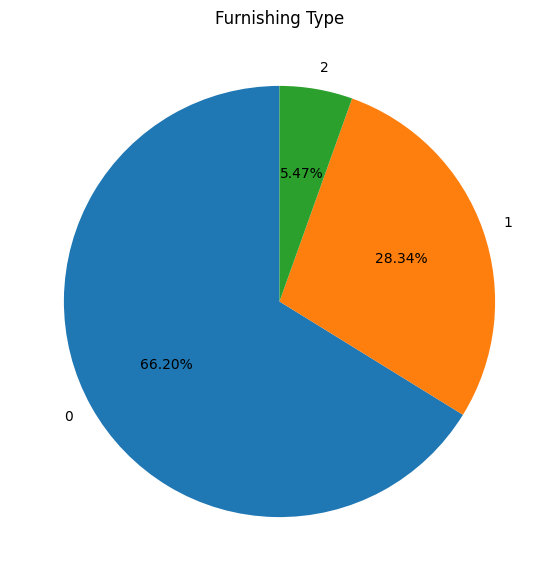

In [172]:
plt.figure(figsize=(7,7))
df["furnishing_type"].value_counts().plot.pie(autopct = '%1.2f%%', startangle = 90, title = 'Furnishing Type', ylabel = "")

# Luxury Score

In [173]:
df["luxury_score"].isnull().sum()

np.int64(0)

In [174]:
df['luxury_score'].value_counts()

,count
luxury_score,
0,465
49,349
174,195
44,60
38,55
...,...
17,3
161,3
147,2


<Axes: xlabel='luxury_score', ylabel='Count'>

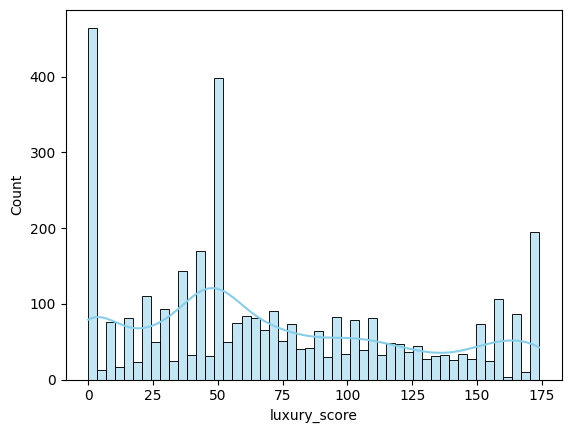

In [175]:
sns.histplot(x=df['luxury_score'], kde=True, bins=50, color='skyblue')

<Axes: xlabel='luxury_score'>

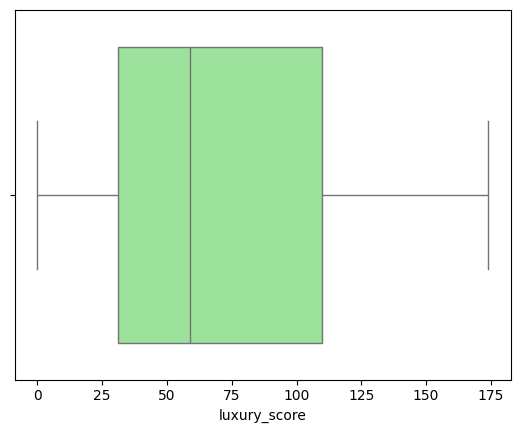

In [176]:
sns.boxplot(x=df['luxury_score'], color='lightgreen')

The luxury score distribution has multiple peaks, suggesting a multi-modal distribution. There's a significant number of properties with lower luxury scores (around 0-50), and another peak is observed around the 110-130 range.

The box plot reveals that the majority of the properties have luxury scores between approximately 30 and 110. The interquartile range (IQR) lies between these values.

In [177]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,indiabulls centrum park,sector 103,1.34,7882.0,1700.08,Super Built up area 1725(160.26 sq.m.)Carpet a...,3,3,3+,...,1725.00,NaN,1700.0,1,1,1,1,0,1,38
1,flat,mapsko royale ville,sector 82,1.15,6424.0,1790.16,Super Built up area 1790(166.3 sq.m.),3,4,2,...,1790.00,NaN,NaN,0,1,0,1,0,1,104
2,flat,ss the leaf,sector 85,2.15,10924.0,1968.14,Super Built up area 2812(261.24 sq.m.)Carpet a...,4,5,3+,...,2812.00,NaN,1968.0,0,1,0,0,0,0,156
3,flat,vatika the seven lamps,sector 82,0.89,8850.0,1005.65,Super Built up area 1428.08(132.67 sq.m.)Carpe...,2,2,2,...,1428.08,NaN,1000.0,1,0,0,0,0,1,129
4,flat,ats triumph,sector 104,1.75,7641.0,2290.28,Super Built up area 2290(212.75 sq.m.)Carpet a...,3,4,3+,...,2290.00,NaN,1800.0,1,1,0,1,1,1,21
